In [1]:
import sys
import os
sys.path.append(os.path.abspath('..'))

import polars as pl
import matplotlib.pyplot as plt

from datetime import datetime

from IPython.display import Markdown, display

from config import (
    SAML_D_VALIDATION_START,
    SAML_D_TEST_START,
    SAML_D_TEST_END_EXCLUSIVE,
    PROCESSED_DATA_DIR
)

from src.data.loader import SAMLDDataLoader
from src.graph.ring_experiment import SAMLDRingExperimentBuilder

In [2]:
### initialize the validation ring experiment
# initialize data loader instance
loader = SAMLDDataLoader()

# transactions
transactions = loader.scan_interim()

# ring experiment directory
ring_experiment_dir = PROCESSED_DATA_DIR / 'graph' / 'ring_expansion_validation'

# create ring experiment instance
ring_experiment = SAMLDRingExperimentBuilder(
    transactions = transactions,
    validation_start = SAML_D_VALIDATION_START,
    validation_end_exclusive = SAML_D_TEST_START,
    output_dir = ring_experiment_dir,
    minimum_ring_size = 3,
    seed_fraction = 0.25,
    minimum_seed_count = 1
)

print(
    f'Validation start: {SAML_D_VALIDATION_START}'
)
print(
    f'Validation end (exclusive): {SAML_D_TEST_START}'
)
print(
    f'Experiment directory: {ring_experiment_dir}'
)

Validation start: 2023-06-01 00:00:00
Validation end (exclusive): 2023-07-01 00:00:00
Experiment directory: /Users/gorkemy/Desktop/Projects/Graph-based Financial Crime/data/processed/graph/ring_expansion_validation


**Experimental Boundaries**

The experiment uses the validation interval *[SAML_D_VALIDATION_START, SAML_D_TEST_START)* to construct retrospective ring labels. The observation graph contains all transactions strictly before **SAML_D_TEST_START**; therefore, the test target window is never read

The observation graph is transductive; it includes unlabeled transaction topology from the validation period. This measures whether Personalized PageRank can complete a partly known ring after some members have been identified. It is not a prospective early-warning claim

In [3]:
### inspect suspicious components - build and summarize suspicious weak components
# component summary
component_summary = ring_experiment.build_component_summary(
    force_rebuild = False
)

# component eligibility summary
component_eligibility_summary = (
    component_summary
    .group_by(
        'is_eligible_ring'
    )
    .agg(
        [
            # component count
            pl.len()
            .alias(
                'component_count'
            ),
            # account count
            pl.col('component_size')
            .sum()
            .alias(
                'account_acount'
            ),
            # minimum size
            pl.col('component_size')
            .min()
            .alias(
                'minimum_size'
            ),
            # median size
            pl.col('component_size')
            .median()
            .alias(
                'median_size'
            ),
            # maximum size
            pl.col('component_size')
            .max()
            .alias(
                'maximum_size'
            )
        ]
    )
    .sort(
        'is_eligible_ring',
        descending = True
    )
)

display(component_summary.head(10))
display(component_eligibility_summary)

raw_component_id,ring_id,canonical_account,component_size,is_eligible_ring
u64,u64,str,u64,bool
24,21,"""1284271707""",13,true
116,91,"""2790497279""",13,true
14,12,"""1202692889""",12,true
28,25,"""1319704443""",12,true
88,67,"""2137169442""",12,true
3,3,"""1042338982""",11,true
35,31,"""137508903""",11,true
39,32,"""1429582712""",11,true
46,38,"""1502125726""",11,true


is_eligible_ring,component_count,account_acount,minimum_size,median_size,maximum_size
bool,u32,u64,u64,f64,u64
true,129,826,3,7.0,13
false,66,132,2,2.0,2


**Suspicious component interpretation**

`is_eligible_ring = True` reports how many suspicious components can support both seed and target accounts. Excluded components are not false or unimportant; they are omitted only because they cannot support the chose ring-expansion design. A very large maximum component or many mixed-typology components would suggest that weak connectivity is merging several generated patters, which should be treated as a limitation of the approximate `ring_id`

**Discussion**

The 1024 suspicious validation transactions from **195 weakly connected components** containing 958 distinct accounts. Requiring at least 3 accounts leaves **129 eligible components** containing **826 accounts**. The remaining 66 components are all 2 connected accounts containing 132 accounts. They are excluded since they provide a nearly trivial expansion task, not because they assumed to be legitimate

Eligible components range from 3 to 13 accounts, with a median size of 7. The relatively compact size distribution and absence of a giant component provide no immediate evidence that weak connectivity is merging a larger number of unrelated patterns

In [4]:
### deterministic seeds and held-out targets - construct ring-level evaluation tables
# ring tables
ring_tables = ring_experiment.build_ring_tables()

rings = ring_tables['rings']
ring_accounts = ring_tables['ring_accounts']
ring_seeds = ring_tables['seeds']
ring_targets = ring_tables['targets']

for table_name, table in ring_tables.items():
    print(
        f'{table_name}: {table.height:,} rows'
    )
    display(table.schema)

rings: 129 rows


Schema([('ring_id', UInt64),
        ('canonical_account', String),
        ('ring_size', UInt64),
        ('seed_count', UInt64),
        ('target_count', UInt64),
        ('suspicious_transaction_count', UInt64),
        ('suspicious_directed_edge_count', UInt64),
        ('first_suspicious_timestamp',
         Datetime(time_unit='us', time_zone=None)),
        ('last_suspicious_timestamp',
         Datetime(time_unit='us', time_zone=None)),
        ('suspicious_active_day_count', UInt64),
        ('laundering_type_count', UInt64),
        ('laundering_types', List(String)),
        ('is_mixed_typology_ring', Boolean),
        ('payment_type_count', UInt64),
        ('payment_currency_count', UInt64),
        ('received_currency_count', UInt64),
        ('cross_currency_transaction_count', UInt64)])

ring_accounts: 826 rows


Schema([('ring_id', UInt64),
        ('node_id', UInt64),
        ('account', String),
        ('ring_member_order', UInt64),
        ('ring_size', UInt64),
        ('seed_count', UInt64),
        ('target_count', UInt64),
        ('first_suspicious_timestamp',
         Datetime(time_unit='us', time_zone=None)),
        ('last_suspicious_timestamp',
         Datetime(time_unit='us', time_zone=None)),
        ('suspicious_sender_event_count', UInt64),
        ('suspicious_receiver_event_count', UInt64),
        ('suspicious_account_event_count', UInt64),
        ('is_ring_seed', Boolean),
        ('is_ring_target', Boolean)])

seeds: 249 rows


Schema([('ring_id', UInt64),
        ('node_id', UInt64),
        ('account', String),
        ('seed_order', UInt64),
        ('ring_size', UInt64),
        ('seed_count', UInt64),
        ('target_count', UInt64),
        ('first_suspicious_timestamp',
         Datetime(time_unit='us', time_zone=None)),
        ('last_suspicious_timestamp',
         Datetime(time_unit='us', time_zone=None)),
        ('suspicious_sender_event_count', UInt64),
        ('suspicious_receiver_event_count', UInt64),
        ('suspicious_account_event_count', UInt64)])

targets: 577 rows


Schema([('ring_id', UInt64),
        ('node_id', UInt64),
        ('account', String),
        ('target_order', UInt64),
        ('ring_size', UInt64),
        ('seed_count', UInt64),
        ('target_count', UInt64),
        ('first_suspicious_timestamp',
         Datetime(time_unit='us', time_zone=None)),
        ('last_suspicious_timestamp',
         Datetime(time_unit='us', time_zone=None)),
        ('suspicious_sender_event_count', UInt64),
        ('suspicious_receiver_event_count', UInt64),
        ('suspicious_account_event_count', UInt64)])

In [5]:
### overall preparation summary
experiment_summary = ring_experiment.build_experiment_summary()

with pl.Config(tbl_cols = -1):
    display(experiment_summary)

validation_start,validation_end_exclusive,validation_suspicious_transaction_count,suspicious_component_count,eligible_ring_count,excluded_component_count,seed_account_count,target_account_count,minimum_ring_size_observed,median_ring_size,maximum_ring_size_observed,mixed_typology_ring_count
datetime[μs],datetime[μs],i64,i64,i64,i64,i64,i64,i64,f64,i64,i64
2023-06-01 00:00:00,2023-07-01 00:00:00,1024,195,129,66,249,577,3,7.0,13,0


In [6]:
### verify seed-withholding invariants
# seed target overlap
seed_target_overlap_count = (
    ring_seeds
    .select(
        'node_id'
    )
    .join(
        ring_targets,
        on = 'node_id',
        how = 'inner'
    )
    .height
)

ring_balance_check = (
    ring_accounts
    .group_by(
        'ring_id'
    )
    .agg(
        [
            # observed ring size
            pl.len()
            .alias(
                'observed_ring_size'
            ),
            # observed seed count
            pl.col('is_ring_seed')
            .sum()
            .alias(
                'observed_seed_count'
            ),
            # observed target count
            pl.col('is_ring_target')
            .sum()
            .alias(
                'observed_target_count'
            )
        ]
    )
    .join(
        rings
        .select(
            [
                'ring_id',
                'ring_size',
                'seed_count',
                'target_count'
            ]
        ),
        on = 'ring_id',
        how = 'left'
    )
)

assert (
    seed_target_overlap_count == 0
)
assert (
    ring_accounts['node_id'].null_count() == 0
)
assert(
    ring_accounts['account'].n_unique() == ring_accounts.height
)
assert(
    ring_accounts
    .filter(
        pl.col('is_ring_seed') == pl.col('is_ring_target')
    )
    .is_empty()
)
assert(
    ring_balance_check
    .filter(
        (pl.col('observed_ring_size') != pl.col('ring_size'))
        | (pl.col('observed_seed_count') != pl.col('seed_count'))
        | (pl.col('observed_target_count') != pl.col('target_count'))
    )
    .is_empty()
)

print(
    'Seed/target checks passed!'
)

Seed/target checks passed!


In [7]:
### inspect ring sizes and the seed/target allocation
ring_size_distribution = (
    rings
    .group_by(
        [
            'ring_size',
            'seed_count',
            'target_count'
        ]
    )
    .agg(
        # ring count
        pl.len()
        .alias(
            'ring_count'
        )
    )
    .sort(
        [
            'ring_size',
            'seed_count'
        ]
    )
)

with pl.Config(tbl_rows = -1):
    display(ring_size_distribution)
    display(
        rings
        .sort(
            'ring_size',
            descending = True
        )
        .head(10)
    )

print(
    f'Seed count: {rings['seed_count'].sum():,}'
)
print(
    f'Target count: {rings['target_count'].sum():,}'
)

ring_size,seed_count,target_count,ring_count
u64,u64,u64,u32
3,1,2,42
4,1,3,4
5,2,3,9
6,2,4,7
7,2,5,14
8,2,6,18
9,3,6,13
10,3,7,11
11,3,8,6


ring_id,canonical_account,ring_size,seed_count,target_count,suspicious_transaction_count,suspicious_directed_edge_count,first_suspicious_timestamp,last_suspicious_timestamp,suspicious_active_day_count,laundering_type_count,laundering_types,is_mixed_typology_ring,payment_type_count,payment_currency_count,received_currency_count,cross_currency_transaction_count
u64,str,u64,u64,u64,u64,u64,datetime[μs],datetime[μs],u64,u64,list[str],bool,u64,u64,u64,u64
21,"""1284271707""",13,4,9,12,12,2023-06-21 08:13:36,2023-06-30 08:11:55,8,1,"[""Fan_In""]",false,1,4,2,12
91,"""2790497279""",13,4,9,13,13,2023-06-04 00:28:58,2023-06-21 23:31:56,13,1,"[""Cycle""]",false,4,3,3,4
12,"""1202692889""",12,3,9,11,11,2023-06-05 09:35:22,2023-06-21 16:46:48,8,1,"[""Gather-Scatter""]",false,4,2,3,4
25,"""1319704443""",12,3,9,25,25,2023-06-09 13:15:01,2023-06-28 14:12:29,14,1,"[""Stacked Bipartite""]",false,5,5,7,12
67,"""2137169442""",12,3,9,14,14,2023-06-01 21:07:18,2023-06-19 19:01:27,11,1,"[""Layered_Fan_In""]",false,5,2,3,3
3,"""1042338982""",11,3,8,10,10,2023-06-09 06:38:20,2023-06-27 12:49:04,7,1,"[""Gather-Scatter""]",false,5,2,4,4
31,"""137508903""",11,3,8,11,11,2023-06-22 01:22:13,2023-06-29 15:35:53,5,1,"[""Layered_Fan_In""]",false,5,1,3,3
32,"""1429582712""",11,3,8,10,10,2023-06-09 14:27:30,2023-06-17 12:46:40,9,1,"[""Structuring""]",false,1,3,2,10
38,"""1502125726""",11,3,8,10,10,2023-06-05 15:51:20,2023-06-14 08:30:50,10,1,"[""Structuring""]",false,5,2,1,1


Seed count: 249
Target count: 577


**Seed-withholding interpretation**

The **129 eligible rings** contain **249 seeds** and **577 held-out targets**. The overall seed share is higher than the configured 25% since $ceil(0.25 * ring\_size)$ is applied separately within every ring; rounding has the greatest effect on small rings. Nevertheless, every eligible component retains at lest one known seed and at least two targets

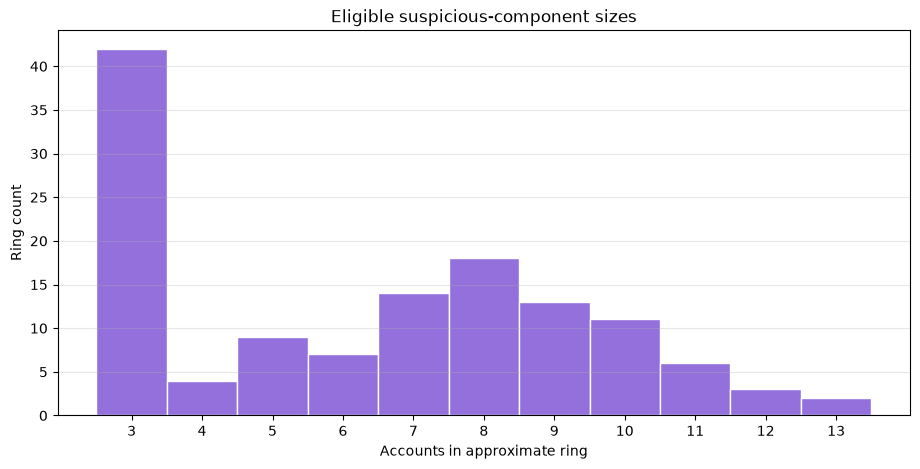

In [8]:
### visualize the eligible ring-size distribution
import numpy as np

ring_sizes = (
    rings.
    get_column(
        'ring_size'
    )
    .to_list()
)

# adjust bin edges & tick positions
minimum_size = min(ring_sizes)
maximum_size = max(ring_sizes)

bin_edges = np.arange(
    minimum_size - 0.5,
    maximum_size + 1.5,
    1,
)

tick_positions = np.arange(
    minimum_size,
    maximum_size + 1,
)

fig, ax = plt.subplots(figsize = (11, 5))

ax.hist(
    ring_sizes,
    bins = bin_edges,
    color = 'mediumpurple',
    edgecolor = 'white'
)
ax.set_title('Eligible suspicious-component sizes')
ax.set_xlabel('Accounts in approximate ring')
ax.set_ylabel('Ring count')
ax.set_xticks(tick_positions)
ax.grid(
    axis = 'y',
    alpha = 0.3
)
plt.show()

In [9]:
### inspect typology purity of approximate rings
typology_purity_summary = (
    rings
    .group_by(
        [
            'laundering_type_count',
            'is_mixed_typology_ring'
        ]
    )
    .agg(
        [
            # ring count
            pl.len()
            .alias(
                'ring_count'
            ),
            # account count
            pl.col('ring_size')
            .sum()
            .alias(
                'account_count'
            )
        ]
    )
    .sort(
        'laundering_type_count'
    )
)

with pl.Config(tbl_rows = -1):
    display(typology_purity_summary)
    display(
        rings.filter(
            pl.col('is_mixed_typology_ring')
        )
        .sort(
            'ring_size',
            descending = True
        )
        .head(10)
    )

laundering_type_count,is_mixed_typology_ring,ring_count,account_count
u64,bool,u32,u64
1,false,129,826


ring_id,canonical_account,ring_size,seed_count,target_count,suspicious_transaction_count,suspicious_directed_edge_count,first_suspicious_timestamp,last_suspicious_timestamp,suspicious_active_day_count,laundering_type_count,laundering_types,is_mixed_typology_ring,payment_type_count,payment_currency_count,received_currency_count,cross_currency_transaction_count
u64,str,u64,u64,u64,u64,u64,datetime[μs],datetime[μs],u64,u64,list[str],bool,u64,u64,u64,u64


**Typology-purity interpretation**

All **129 eligible rings** contain exactly one laundering-type label; noe is marked as mixed-typology component. This is reassuring since weak connectivity has not visibly joined patterns with different typologies. It does not prove that each component is a true individual ring. However, separate generated patterns of the same typology could still merge if they share an account. Consequently, `ring_id` remains an approximate evaluation label rather than native ground truth

In [10]:
### generate a concise interpretation from the observed preparation results
summary_row = experiment_summary.row(
    0,
    named = True 
)

display(summary_row)

# total accounts contained in the aligible rings
eligible_account_count = (
    summary_row['seed_account_count'] + summary_row['target_account_count']
)

# share of suspicious components satisfying the eligibility rule
eligible_component_share = (
    summary_row['eligible_ring_count'] / summary_row['suspicious_component_count']
)

# share of eligible accounts reserved as held-out targets
target_share = (
    summary_row['target_account_count'] / eligible_account_count
)

# share of eligible rings containing multiple typology labels
mixed_ring_share = (
    summary_row['mixed_typology_ring_count'] / summary_row['eligible_ring_count']
)

display(
    Markdown(
        f"""
**Preparation interpretation**: The validation labels form **{summary_row['suspicious_component_count']:,}** suspicious weak components.
After requiring at least three account, **{summary_row['eligible_ring_count']:,}** components remain ({eligible_component_share:.1%}). 

These eligible components contain
**{eligible_account_count:,}** accounts:
**{summary_row['seed_account_count']:,}** seeds and 
**{summary_row['target_account_count']:,}** held-out targets ({target_share:.1%} of eligible accounts). 

Ring sizes range from
**{summary_row['minimum_ring_size_observed']:,}** to **{summary_row['maximum_ring_size_observed']:,}**, with median
**{summary_row['median_ring_size']:.1f}**. 

Finally, **{summary_row['mixed_typology_ring_count']:,}** rings ({mixed_ring_share:.1%}) contain multiple laundering-type labels; those cases 
show where weak-component reconstruction may have merged more than one generated pattern.
"""
    )
)

{'validation_start': datetime.datetime(2023, 6, 1, 0, 0),
 'validation_end_exclusive': datetime.datetime(2023, 7, 1, 0, 0),
 'validation_suspicious_transaction_count': 1024,
 'suspicious_component_count': 195,
 'eligible_ring_count': 129,
 'excluded_component_count': 66,
 'seed_account_count': 249,
 'target_account_count': 577,
 'minimum_ring_size_observed': 3,
 'median_ring_size': 7.0,
 'maximum_ring_size_observed': 13,
 'mixed_typology_ring_count': 0}


**Preparation interpretation**: The validation labels form **195** suspicious weak components.
After requiring at least three account, **129** components remain (66.2%). 

These eligible components contain
**826** accounts:
**249** seeds and 
**577** held-out targets (69.9% of eligible accounts). 

Ring sizes range from
**3** to **13**, with median
**7.0**. 

Finally, **0** rings (0.0%) contain multiple laundering-type labels; those cases 
show where weak-component reconstruction may have merged more than one generated pattern.


In [11]:
### verify label separation - inspect observation schemas and enfore label separation
observation_graph_tables = ring_experiment.build_observation_graph_tables()

# node columns
node_columns = set(
    observation_graph_tables['nodes']
    .collect_schema()
    .names()
)

# edge columns
edge_columns = set(
    observation_graph_tables['edges']
    .collect_schema()
    .names()
)

# define columns to ensure that observation graph is label-free
forbidden_label_columns = {
    'is_laundering',
    'laundering_type'
}

min_target_timestamp = ring_targets['first_suspicious_timestamp'].min()
max_target_timestamp = ring_targets['first_suspicious_timestamp'].max()

if not isinstance(min_target_timestamp, datetime):
    raise TypeError(
        'min_target_timestamp must be a datetime instance'
    )

if not isinstance(max_target_timestamp, datetime):
    raise TypeError(
        'max_target_timestamp must be a datetime instance'
    )
    
assert(
    forbidden_label_columns.isdisjoint(node_columns)
)
assert(
    forbidden_label_columns.isdisjoint(edge_columns)
)
assert(
    min_target_timestamp >= SAML_D_VALIDATION_START
)
assert(
    max_target_timestamp < SAML_D_TEST_START
)

display(observation_graph_tables['nodes'].collect_schema())
display(observation_graph_tables['edges'].collect_schema())
print('Observation graph is label-free and all targets precede test start window')


Schema([('node_id', UInt64),
        ('account', String),
        ('first_seen_timestamp', Datetime(time_unit='us', time_zone=None)),
        ('last_seen_timestamp', Datetime(time_unit='us', time_zone=None)),
        ('outgoing_transaction_count', UInt64),
        ('incoming_transaction_count', UInt64),
        ('account_transaction_event_count', UInt64),
        ('out_degree', UInt64),
        ('in_degree', UInt64),
        ('total_directed_degree', UInt64),
        ('bank_location_count', UInt64),
        ('is_multi_location', Boolean),
        ('has_outgoing_activity', Boolean),
        ('has_incoming_activity', Boolean)])

Schema([('edge_id', UInt64),
        ('source_node_id', UInt64),
        ('target_node_id', UInt64),
        ('sender_account', String),
        ('receiver_account', String),
        ('transaction_count', UInt64),
        ('count_weight', Float64),
        ('log_count_weight', Float64),
        ('first_transaction_timestamp',
         Datetime(time_unit='us', time_zone=None)),
        ('last_transaction_timestamp',
         Datetime(time_unit='us', time_zone=None)),
        ('active_day_count', UInt64),
        ('payment_type_count', UInt64),
        ('payment_currency_count', UInt64),
        ('received_currency_count', UInt64),
        ('cross_currency_transaction_count', UInt64),
        ('cross_currency_share', Float64),
        ('is_repeated_edge', Boolean),
        ('is_self_loop', Boolean)])

Observation graph is label-free and all targets precede test start window


**Label-separation interpretation**

Neither `is_laundering` nor `laundering_type` appears in the observation node or edge schema. Ring membershp, seed status, target status, and typology remain isolated in evaluation tables. The earlist and latest target activity also remain inside the validation interval, so the test window is untouched

The graph nevertheless contains unlabeled validation-period edges, including edges later used to reconstruct the approximate rings

In [12]:
### persist the experiment - persist graph and evaluation tables
experiment_paths = ring_experiment.write_experiment(
    overwrite = False
)

display(experiment_paths.as_dict())

{'nodes': PosixPath('/Users/gorkemy/Desktop/Projects/Graph-based Financial Crime/data/processed/graph/ring_expansion_validation/nodes.parquet'),
 'edges': PosixPath('/Users/gorkemy/Desktop/Projects/Graph-based Financial Crime/data/processed/graph/ring_expansion_validation/edges.parquet'),
 'rings': PosixPath('/Users/gorkemy/Desktop/Projects/Graph-based Financial Crime/data/processed/graph/ring_expansion_validation/rings.parquet'),
 'ring_accounts': PosixPath('/Users/gorkemy/Desktop/Projects/Graph-based Financial Crime/data/processed/graph/ring_expansion_validation/ring_accounts.parquet'),
 'seeds': PosixPath('/Users/gorkemy/Desktop/Projects/Graph-based Financial Crime/data/processed/graph/ring_expansion_validation/seeds.parquet'),
 'targets': PosixPath('/Users/gorkemy/Desktop/Projects/Graph-based Financial Crime/data/processed/graph/ring_expansion_validation/targets.parquet'),
 'manifest': PosixPath('/Users/gorkemy/Desktop/Projects/Graph-based Financial Crime/data/processed/graph/ring_

In [13]:
### check Personalized PageRank feasibility 
# compute reachability from the persisted observation graph
reachability_summary = ring_experiment.build_reachability_summary(
    use_persisted_graph = True
)

with pl.Config(tbl_cols = -1):
    display(reachability_summary)

assert(
    reachability_summary['weakly_reachable_target_count'][0] == ring_targets.height
)

observation_node_count,observation_edge_count,weakly_reachable_target_count,weakly_reachable_target_share,forward_reachable_target_count,forward_reachable_target_share,reverse_reachable_target_count,reverse_reachable_target_share,either_direction_reachable_target_count,either_direction_reachable_target_share
i64,i64,i64,f64,i64,f64,i64,f64,i64,f64
780262,807600,577,1.0,317,0.549393,251,0.435009,547,0.948007


In [14]:
### generate the reachability interpretation
reachability_row = (
    reachability_summary
    .row(
        0,
        named = True
    )
)

target_count = ring_targets.height

forward_count = reachability_row['forward_reachable_target_count']
reverse_count = reachability_row['reverse_reachable_target_count']
either_count = reachability_row['either_direction_reachable_target_count']
both_direction_count = forward_count + reverse_count - either_count
forward_only_count = forward_count - both_direction_count
reverse_only_count = reverse_count - both_direction_count
neither_direction_count = target_count - either_count

display(
    Markdown(
        f"""
**PPR-feasibility interpretation** 
All **{target_count:,}** withheld targets are weakly connected to at least one pooled seed. This 100% weak-reachability result is an expected integrity check 
because rings were defined from weak components whose transaction edges are included in the observation graph; it is not evidence of ranking performance

Forward paths reach **{forward_count:,} targets ({reachability_row['forward_reachable_target_share']:.1%})**, 
while reverse paths reach **{reverse_count:,} ({reachability_row['reverse_reachable_target_share']:.1%})**. 
The union covers **{either_count:,} targets ({reachability_row['either_direction_reachable_target_share']:.1%})**: 
{forward_only_count:,} are forward-only, 
{reverse_only_count:,} are reverse-only, 
{both_direction_count:,} are reachable in both directions, 
and {neither_direction_count:,} are weakly connected but directionally unreachable in either version. 
Forward PPR has the broader initial coverage, but neither direction should be used alone

These are pooled-seed diagnostics: a target may be reachable from any of the 249 seeds, not necessarily a seed from its own approximate ring. 
The next notebook must therefore report ring-specific evaluation in addition to a pooled candidate ranking
"""
    )
)



**PPR-feasibility interpretation** 
All **577** withheld targets are weakly connected to at least one pooled seed. This 100% weak-reachability result is an expected integrity check 
because rings were defined from weak components whose transaction edges are included in the observation graph; it is not evidence of ranking performance

Forward paths reach **317 targets (54.9%)**, 
while reverse paths reach **251 (43.5%)**. 
The union covers **547 targets (94.8%)**: 
296 are forward-only, 
230 are reverse-only, 
21 are reachable in both directions, 
and 30 are weakly connected but directionally unreachable in either version. 
Forward PPR has the broader initial coverage, but neither direction should be used alone

These are pooled-seed diagnostics: a target may be reachable from any of the 249 seeds, not necessarily a seed from its own approximate ring. 
The next notebook must therefore report ring-specific evaluation in addition to a pooled candidate ranking


In [15]:
### reopen persisted artifacts and report file-level row counts
saved_tables = ring_experiment.scan_experiment()

saved_table_summary = pl.concat(
    [
        lazy_table
        .select(
            [
                pl.lit(table_name).alias('table'),
                pl.len().cast(pl.UInt64).alias('row_count')
            ]
        )
        .collect(engine = 'streaming')
        for table_name, lazy_table in saved_tables.items()
    ],
    how = 'vertical'
)

display(saved_table_summary)

table,row_count
str,u64
"""nodes""",780262
"""edges""",807600
"""rings""",129
"""ring_accounts""",826
"""seeds""",249
"""targets""",577


**Conclusion**

The persisted tables reconcile exactly; 780k nodes, 807k aggregated directed edges, 129 approximate rings, 826 ring accounts, 249 seeds, and 577 held-out targets. The graph is larger than the earlier validation snapshot since this transductive experiment intentionally observes transactions through cutoff